In [1]:
# ============================================================
# Homework 2 - Deep Learning
# Problem 1: Next Character Prediction with rnn.RNN, rnn.LSTM, rnn.GRU
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [2]:
# --- Problem 1: Dataset Preparation ---

text = "This is a simple example to demonstrate how to predict the next character using RNN in PyTorch."

# Build character vocabulary
chars = sorted(list(set(text)))
vocab_size = len(chars)
ix_to_char = {i: ch for i, ch in enumerate(chars)}
char_to_ix = {ch: i for i, ch in enumerate(chars)}
print(f'Vocabulary size: {vocab_size}')
print(f'Characters: {chars}')

Vocabulary size: 25
Characters: [' ', '.', 'N', 'P', 'R', 'T', 'a', 'c', 'd', 'e', 'g', 'h', 'i', 'l', 'm', 'n', 'o', 'p', 'r', 's', 't', 'u', 'w', 'x', 'y']


In [3]:
# --- Problem 1: Model Definitions ---

class CharRNNModel(nn.Module):
    """Generic character-level model supporting RNN, LSTM, and GRU."""
    def __init__(self, vocab_size, hidden_size, output_size, model_type='RNN', num_layers=1):
        super(CharRNNModel, self).__init__()
        self.model_type = model_type
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.embedding = nn.Embedding(vocab_size, hidden_size)
        if model_type == 'RNN':
            self.rnn = nn.RNN(hidden_size, hidden_size, num_layers=num_layers, batch_first=True)
        elif model_type == 'LSTM':
            self.rnn = nn.LSTM(hidden_size, hidden_size, num_layers=num_layers, batch_first=True)
        elif model_type == 'GRU':
            self.rnn = nn.GRU(hidden_size, hidden_size, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        embedded = self.embedding(x)
        output, _ = self.rnn(embedded)
        output = self.fc(output[:, -1, :])
        return output

print('Model class defined.')

Model class defined.


In [4]:
# --- Problem 1: Helper functions for model complexity ---

def count_parameters(model):
    """Count total trainable parameters."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def compute_flops_rnn(model_type, input_size, hidden_size, seq_len, num_layers=1):
    """
    Approximate FLOPs for one forward pass.
    RNN:  4*H*(H+I) per timestep (2 matmuls, no gates)
    LSTM: 4*H*(H+I)*4 gates per timestep
    GRU:  4*H*(H+I)*3 gates per timestep
    """
    H, I = hidden_size, input_size
    if model_type == 'RNN':
        flops_per_step = 2 * H * (H + I)   # one tanh gate
    elif model_type == 'LSTM':
        flops_per_step = 8 * H * (H + I)   # 4 gates, each with 2 matmuls fused
    elif model_type == 'GRU':
        flops_per_step = 6 * H * (H + I)   # 3 gates
    return flops_per_step * seq_len * num_layers

print('Helper functions defined.')

Helper functions defined.


In [5]:
# --- Problem 1: Training and Evaluation Loop ---

def build_dataset_p1(text, char_to_ix, max_length):
    X, y = [], []
    for i in range(len(text) - max_length):
        sequence = text[i:i + max_length]
        label = text[i + max_length]
        X.append([char_to_ix[c] for c in sequence])
        y.append(char_to_ix[label])
    X = np.array(X)
    y = np.array(y)
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
    X_train = torch.tensor(X_train, dtype=torch.long).to(device)
    y_train = torch.tensor(y_train, dtype=torch.long).to(device)
    X_val   = torch.tensor(X_val,   dtype=torch.long).to(device)
    y_val   = torch.tensor(y_val,   dtype=torch.long).to(device)
    return X_train, X_val, y_train, y_val

def train_model_p1(model_type, seq_len, vocab_size, hidden_size=128, epochs=150, lr=0.005):
    X_train, X_val, y_train, y_val = build_dataset_p1(text, char_to_ix, seq_len)
    model = CharRNNModel(vocab_size, hidden_size, vocab_size, model_type=model_type).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    start_time = time.time()
    train_losses, val_losses, val_accs = [], [], []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        output = model(X_train)
        loss = criterion(output, y_train)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_output = model(X_val)
            val_loss = criterion(val_output, y_val)
            _, predicted = torch.max(val_output, 1)
            val_acc = (predicted == y_val).float().mean().item()
        val_losses.append(val_loss.item())
        val_accs.append(val_acc)

    exec_time = time.time() - start_time
    params = count_parameters(model)
    flops = compute_flops_rnn(model_type, hidden_size, hidden_size, seq_len)
    model_size_kb = params * 4 / 1024  # float32 = 4 bytes

    print(f'  [{model_type} | seq={seq_len}] Final Train Loss: {train_losses[-1]:.4f} | '
          f'Val Loss: {val_losses[-1]:.4f} | Val Acc: {val_accs[-1]*100:.2f}% | '
          f'Time: {exec_time:.2f}s | Params: {params:,} | '
          f'FLOPs: {flops:,} | Size: {model_size_kb:.1f} KB')
    return train_losses, val_losses, val_accs, exec_time, params, flops, model_size_kb

print('Training function defined.')

Training function defined.


In [6]:
# --- Problem 1: Run all experiments ---

print('='*70)
print('PROBLEM 1: rnn.RNN, rnn.LSTM, rnn.GRU on character sequence')
print('='*70)

seq_lengths = [10, 20, 30]
model_types = ['RNN', 'LSTM', 'GRU']
results_p1 = {}

for seq_len in seq_lengths:
    print(f'\n--- Sequence Length: {seq_len} ---')
    for model_type in model_types:
        key = f'{model_type}_seq{seq_len}'
        res = train_model_p1(model_type, seq_len, vocab_size)
        results_p1[key] = res

print('\nDone with Problem 1!')

PROBLEM 1: rnn.RNN, rnn.LSTM, rnn.GRU on character sequence

--- Sequence Length: 10 ---
  [RNN | seq=10] Final Train Loss: 0.0007 | Val Loss: 7.9614 | Val Acc: 11.76% | Time: 0.69s | Params: 39,449 | FLOPs: 655,360 | Size: 154.1 KB
  [LSTM | seq=10] Final Train Loss: 0.0009 | Val Loss: 7.7849 | Val Acc: 0.00% | Time: 0.15s | Params: 138,521 | FLOPs: 2,621,440 | Size: 541.1 KB
  [GRU | seq=10] Final Train Loss: 0.0007 | Val Loss: 8.4564 | Val Acc: 0.00% | Time: 0.15s | Params: 105,497 | FLOPs: 1,966,080 | Size: 412.1 KB

--- Sequence Length: 20 ---
  [RNN | seq=20] Final Train Loss: 0.0007 | Val Loss: 7.1486 | Val Acc: 0.00% | Time: 0.16s | Params: 39,449 | FLOPs: 1,310,720 | Size: 154.1 KB
  [LSTM | seq=20] Final Train Loss: 0.0009 | Val Loss: 7.4302 | Val Acc: 0.00% | Time: 0.15s | Params: 138,521 | FLOPs: 5,242,880 | Size: 541.1 KB
  [GRU | seq=20] Final Train Loss: 0.0007 | Val Loss: 7.5743 | Val Acc: 6.67% | Time: 0.14s | Params: 105,497 | FLOPs: 3,932,160 | Size: 412.1 KB

--- Se


Summary Table - Problem 1:
Model    SeqLen   Train Loss   Val Loss     Val Acc    Time(s)    Params     FLOPs           Size(KB)
----------------------------------------------------------------------------------------------------
RNN      10       0.0007       7.9614       11.76      0.69       39,449     655,360         154.1
LSTM     10       0.0009       7.7849       0.00       0.15       138,521    2,621,440       541.1
GRU      10       0.0007       8.4564       0.00       0.15       105,497    1,966,080       412.1
RNN      20       0.0007       7.1486       0.00       0.16       39,449     1,310,720       154.1
LSTM     20       0.0009       7.4302       0.00       0.15       138,521    5,242,880       541.1
GRU      20       0.0007       7.5743       6.67       0.14       105,497    3,932,160       412.1
RNN      30       0.0007       6.7564       0.00       0.13       39,449     1,966,080       154.1
LSTM     30       0.0009       7.1809       0.00       0.15       138,521   

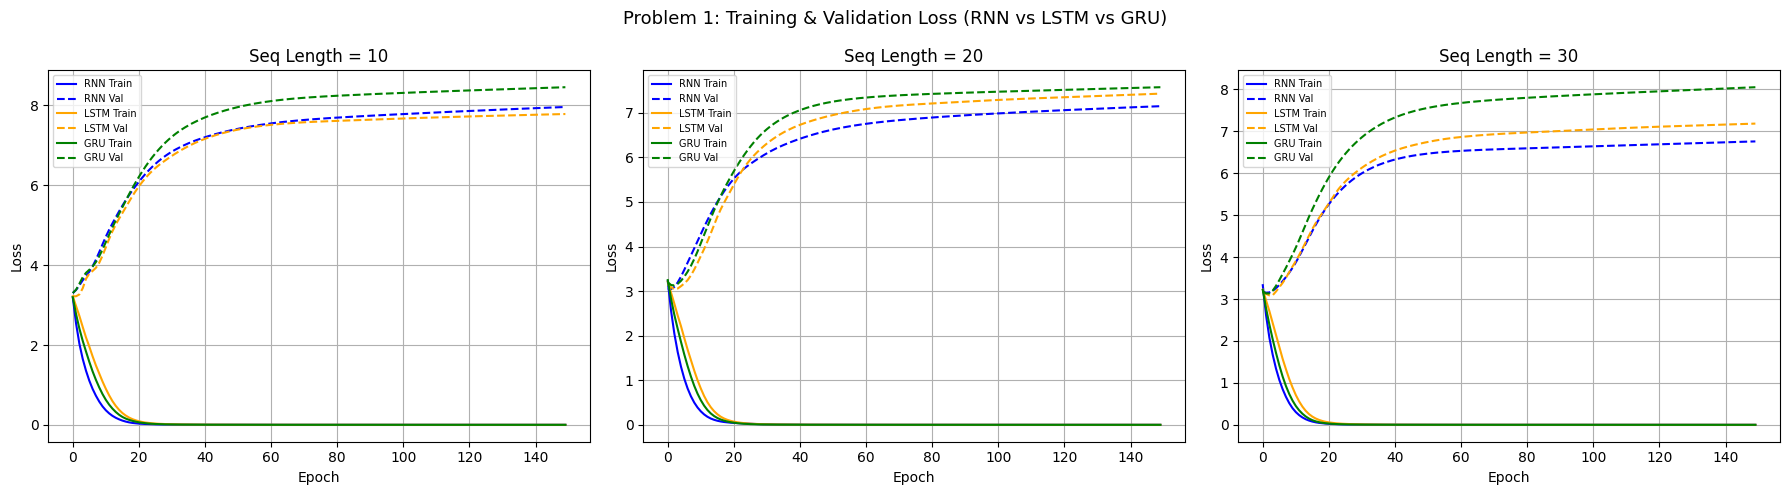

Plot saved as p1_loss_curves.png


In [7]:
# --- Problem 1: Summary Table and Loss Plots ---

print('\nSummary Table - Problem 1:')
print(f'{"Model":<8} {"SeqLen":<8} {"Train Loss":<12} {"Val Loss":<12} {"Val Acc":<10} {"Time(s)":<10} {"Params":<10} {"FLOPs":<15} {"Size(KB)"}')
print('-'*100)

for seq_len in seq_lengths:
    for model_type in model_types:
        key = f'{model_type}_seq{seq_len}'
        tl, vl, va, et, params, flops, size = results_p1[key]
        print(f'{model_type:<8} {seq_len:<8} {tl[-1]:<12.4f} {vl[-1]:<12.4f} {va[-1]*100:<10.2f} {et:<10.2f} {params:<10,} {flops:<15,} {size:.1f}')

# Plot training loss curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = {'RNN': 'blue', 'LSTM': 'orange', 'GRU': 'green'}

for idx, seq_len in enumerate(seq_lengths):
    ax = axes[idx]
    for model_type in model_types:
        key = f'{model_type}_seq{seq_len}'
        tl, vl, va, et, params, flops, size = results_p1[key]
        ax.plot(tl, label=f'{model_type} Train', color=colors[model_type], linestyle='-')
        ax.plot(vl, label=f'{model_type} Val', color=colors[model_type], linestyle='--')
    ax.set_title(f'Seq Length = {seq_len}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=7)
    ax.grid(True)

plt.suptitle('Problem 1: Training & Validation Loss (RNN vs LSTM vs GRU)', fontsize=13)
plt.tight_layout()
plt.savefig('p1_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved as p1_loss_curves.png')

In [8]:
# ============================================================
# PROBLEM 2: LSTM and GRU for tiny Shakespeare dataset
# ============================================================

import requests
from torch.utils.data import Dataset, DataLoader

# Step 1: Download the dataset
print('Downloading tiny Shakespeare dataset...')
url = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
response = requests.get(url)
shake_text = response.text
print(f'Dataset loaded. Length: {len(shake_text):,} characters')

# Step 2: Build vocabulary
shake_chars = sorted(list(set(shake_text)))
shake_vocab_size = len(shake_chars)
shake_char_to_int = {ch: i for i, ch in enumerate(shake_chars)}
shake_int_to_char = {i: ch for i, ch in enumerate(shake_chars)}
print(f'Vocabulary size: {shake_vocab_size}')

Dataset loaded. Length: 1,115,394 characters
Vocabulary size: 65


In [9]:
# --- Problem 2: Dataset Class and DataLoader builder ---

class CharDataset(Dataset):
    def __init__(self, sequences, targets):
        self.sequences = sequences
        self.targets = targets
    def __len__(self):
        return len(self.sequences)
    def __getitem__(self, index):
        return self.sequences[index], self.targets[index]

def build_shakespeare_loaders(seq_len, batch_size=256):
    encoded = [shake_char_to_int[ch] for ch in shake_text]
    sequences, targets = [], []
    for i in range(len(encoded) - seq_len):
        sequences.append(encoded[i:i + seq_len])
        targets.append(encoded[i + seq_len])
    seqs = torch.tensor(sequences, dtype=torch.long)
    tgts = torch.tensor(targets,   dtype=torch.long)
    dataset = CharDataset(seqs, tgts)
    train_size = int(len(dataset) * 0.8)
    val_size   = len(dataset) - train_size
    train_ds, val_ds = torch.utils.data.random_split(dataset, [train_size, val_size])
    train_loader = DataLoader(train_ds, shuffle=True,  batch_size=batch_size, pin_memory=True)
    val_loader   = DataLoader(val_ds,   shuffle=False, batch_size=batch_size, pin_memory=True)
    return train_loader, val_loader

print('CharDataset and loader builder defined.')

CharDataset and loader builder defined.


In [10]:
# --- Problem 2: Shakespeare Model and Training Function ---

class ShakespeareModel(nn.Module):
    """LSTM/GRU model for the Shakespeare char-level task."""
    def __init__(self, vocab_size, embed_size, hidden_size, output_size, model_type='LSTM', num_layers=1, fc_hidden=None):
        super(ShakespeareModel, self).__init__()
        self.model_type = model_type
        self.embedding = nn.Embedding(vocab_size, embed_size)
        if model_type == 'LSTM':
            self.rnn = nn.LSTM(embed_size, hidden_size, num_layers=num_layers, batch_first=True, dropout=0.2 if num_layers>1 else 0)
        elif model_type == 'GRU':
            self.rnn = nn.GRU(embed_size, hidden_size, num_layers=num_layers, batch_first=True, dropout=0.2 if num_layers>1 else 0)
        # Optional fully-connected hidden layer
        if fc_hidden is not None:
            self.fc = nn.Sequential(nn.Linear(hidden_size, fc_hidden), nn.ReLU(), nn.Linear(fc_hidden, output_size))
        else:
            self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        emb = self.embedding(x)
        out, _ = self.rnn(emb)
        out = self.fc(out[:, -1, :])
        return out

def train_shakespeare(model_type, seq_len, hidden_size=256, embed_size=128,
                      num_layers=1, fc_hidden=None, epochs=10, lr=0.001, batch_size=256, label=''):
    train_loader, val_loader = build_shakespeare_loaders(seq_len, batch_size=batch_size)
    model = ShakespeareModel(shake_vocab_size, embed_size, hidden_size, shake_vocab_size,
                              model_type=model_type, num_layers=num_layers, fc_hidden=fc_hidden).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses, val_losses, val_accs = [], [], []
    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for seqs, tgts in train_loader:
            seqs, tgts = seqs.to(device), tgts.to(device)
            optimizer.zero_grad()
            out = model(seqs)
            loss = criterion(out, tgts)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            epoch_loss += loss.item() * seqs.size(0)
        epoch_loss /= len(train_loader.dataset)
        train_losses.append(epoch_loss)

        model.eval()
        val_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for seqs, tgts in val_loader:
                seqs, tgts = seqs.to(device), tgts.to(device)
                out = model(seqs)
                loss = criterion(out, tgts)
                val_loss += loss.item() * seqs.size(0)
                preds = torch.argmax(out, dim=1)
                correct += (preds == tgts).sum().item()
                total += tgts.size(0)
        val_loss /= len(val_loader.dataset)
        val_acc = correct / total
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        perplexity = np.exp(val_loss)
        print(f'  Epoch {epoch+1}/{epochs} | TrLoss={epoch_loss:.4f} | ValLoss={val_loss:.4f} | ValAcc={val_acc*100:.2f}% | PPL={perplexity:.2f}')

    exec_time = time.time() - start_time
    params = count_parameters(model)
    model_size_kb = params * 4 / 1024
    flops = compute_flops_rnn(model_type, embed_size, hidden_size, seq_len, num_layers)
    final_ppl = np.exp(val_losses[-1])

    tag = label or f'{model_type}|seq={seq_len}|H={hidden_size}|L={num_layers}|fc={fc_hidden}'
    print(f'\n  [{tag}] Time={exec_time:.1f}s | Params={params:,} | Size={model_size_kb:.1f}KB | FLOPs={flops:,} | Final PPL={final_ppl:.2f}')
    return train_losses, val_losses, val_accs, exec_time, params, model_size_kb, flops, final_ppl

print('ShakespeareModel and training function defined.')

ShakespeareModel and training function defined.


In [11]:
# --- Problem 2.1: LSTM and GRU for seq_len=20 and 30 ---

print('='*70)
print('PROBLEM 2.1: LSTM and GRU - seq_len 20 and 30')
print('='*70)

results_p2 = {}

for seq_len in [20, 30]:
    for model_type in ['LSTM', 'GRU']:
        label = f'{model_type}_seq{seq_len}'
        print(f'\n--- {label} ---')
        res = train_shakespeare(model_type, seq_len, hidden_size=256, embed_size=128,
                                num_layers=1, epochs=10, label=label)
        results_p2[label] = res

print('\nDone with Problem 2.1!')

PROBLEM 2.1: LSTM and GRU - seq_len 20 and 30

--- LSTM_seq20 ---
  Epoch 1/10 | TrLoss=1.7724 | ValLoss=1.5494 | ValAcc=53.20% | PPL=4.71
  Epoch 2/10 | TrLoss=1.4901 | ValLoss=1.4607 | ValAcc=55.40% | PPL=4.31
  Epoch 3/10 | TrLoss=1.4171 | ValLoss=1.4183 | ValAcc=56.62% | PPL=4.13
  Epoch 4/10 | TrLoss=1.3747 | ValLoss=1.3953 | ValAcc=57.22% | PPL=4.04
  Epoch 5/10 | TrLoss=1.3463 | ValLoss=1.3788 | ValAcc=57.65% | PPL=3.97
  Epoch 6/10 | TrLoss=1.3242 | ValLoss=1.3685 | ValAcc=57.99% | PPL=3.93
  Epoch 7/10 | TrLoss=1.3066 | ValLoss=1.3633 | ValAcc=58.07% | PPL=3.91
  Epoch 8/10 | TrLoss=1.2916 | ValLoss=1.3613 | ValAcc=58.16% | PPL=3.90
  Epoch 9/10 | TrLoss=1.2793 | ValLoss=1.3569 | ValAcc=58.42% | PPL=3.88
  Epoch 10/10 | TrLoss=1.2678 | ValLoss=1.3512 | ValAcc=58.49% | PPL=3.86

  [LSTM_seq20] Time=77.3s | Params=420,289 | Size=1641.8KB | FLOPs=15,728,640 | Final PPL=3.86

--- GRU_seq20 ---
  Epoch 1/10 | TrLoss=1.7244 | ValLoss=1.5379 | ValAcc=53.63% | PPL=4.65
  Epoch 2/10 | 

In [12]:
# --- Problem 2.2: Hyperparameter Tuning ---
# Vary: fc_hidden (fully connected layers), num_layers (hidden layers), hidden_size (hidden states)

print('='*70)
print('PROBLEM 2.2: Hyperparameter Tuning on Shakespeare (LSTM, seq_len=20)')
print('='*70)

hp_configs = [
    # (hidden_size, num_layers, fc_hidden, label)
    (256, 1, None,  'Baseline H=256 L=1'),
    (256, 2, None,  'L=2 (more hidden layers)'),
    (128, 1, None,  'H=128 (fewer hidden states)'),
    (512, 1, None,  'H=512 (more hidden states)'),
    (256, 1, 512,   'FC hidden=512'),
    (256, 1, 128,   'FC hidden=128'),
]

results_hp = {}
for (h, l, fc, lbl) in hp_configs:
    print(f'\n--- Config: {lbl} ---')
    res = train_shakespeare('LSTM', seq_len=20, hidden_size=h, embed_size=128,
                             num_layers=l, fc_hidden=fc, epochs=8, label=lbl)
    results_hp[lbl] = res

print('\nDone with Problem 2.2!')

PROBLEM 2.2: Hyperparameter Tuning on Shakespeare (LSTM, seq_len=20)

--- Config: Baseline H=256 L=1 ---
  Epoch 1/8 | TrLoss=1.7747 | ValLoss=1.5524 | ValAcc=53.37% | PPL=4.72
  Epoch 2/8 | TrLoss=1.4885 | ValLoss=1.4600 | ValAcc=55.58% | PPL=4.31
  Epoch 3/8 | TrLoss=1.4150 | ValLoss=1.4157 | ValAcc=56.70% | PPL=4.12
  Epoch 4/8 | TrLoss=1.3732 | ValLoss=1.3961 | ValAcc=57.25% | PPL=4.04
  Epoch 5/8 | TrLoss=1.3451 | ValLoss=1.3788 | ValAcc=57.74% | PPL=3.97
  Epoch 6/8 | TrLoss=1.3230 | ValLoss=1.3706 | ValAcc=57.80% | PPL=3.94
  Epoch 7/8 | TrLoss=1.3052 | ValLoss=1.3609 | ValAcc=58.07% | PPL=3.90
  Epoch 8/8 | TrLoss=1.2902 | ValLoss=1.3615 | ValAcc=58.12% | PPL=3.90

  [Baseline H=256 L=1] Time=61.6s | Params=420,289 | Size=1641.8KB | FLOPs=15,728,640 | Final PPL=3.90

--- Config: L=2 (more hidden layers) ---
  Epoch 1/8 | TrLoss=1.7845 | ValLoss=1.5194 | ValAcc=53.98% | PPL=4.57
  Epoch 2/8 | TrLoss=1.4821 | ValLoss=1.4226 | ValAcc=56.21% | PPL=4.15
  Epoch 3/8 | TrLoss=1.4096 |

In [13]:
# --- Problem 2.3: Sequence Length = 50 ---

print('='*70)
print('PROBLEM 2.3: LSTM and GRU with seq_len=50')
print('='*70)

results_p23 = {}
for model_type in ['LSTM', 'GRU']:
    label = f'{model_type}_seq50'
    print(f'\n--- {label} ---')
    res = train_shakespeare(model_type, seq_len=50, hidden_size=256, embed_size=128,
                            num_layers=1, epochs=10, label=label)
    results_p23[label] = res

print('\nDone with Problem 2.3!')

PROBLEM 2.3: LSTM and GRU with seq_len=50

--- LSTM_seq50 ---
  Epoch 1/10 | TrLoss=1.7644 | ValLoss=1.5427 | ValAcc=53.32% | PPL=4.68
  Epoch 2/10 | TrLoss=1.4761 | ValLoss=1.4451 | ValAcc=55.78% | PPL=4.24
  Epoch 3/10 | TrLoss=1.4008 | ValLoss=1.4068 | ValAcc=56.83% | PPL=4.08
  Epoch 4/10 | TrLoss=1.3582 | ValLoss=1.3852 | ValAcc=57.45% | PPL=4.00
  Epoch 5/10 | TrLoss=1.3290 | ValLoss=1.3611 | ValAcc=58.04% | PPL=3.90
  Epoch 6/10 | TrLoss=1.3066 | ValLoss=1.3519 | ValAcc=58.44% | PPL=3.86
  Epoch 7/10 | TrLoss=1.2886 | ValLoss=1.3478 | ValAcc=58.37% | PPL=3.85
  Epoch 8/10 | TrLoss=1.2731 | ValLoss=1.3376 | ValAcc=58.93% | PPL=3.81
  Epoch 9/10 | TrLoss=1.2595 | ValLoss=1.3385 | ValAcc=58.86% | PPL=3.81
  Epoch 10/10 | TrLoss=1.2490 | ValLoss=1.3339 | ValAcc=58.94% | PPL=3.80

  [LSTM_seq50] Time=107.9s | Params=420,289 | Size=1641.8KB | FLOPs=39,321,600 | Final PPL=3.80

--- GRU_seq50 ---
  Epoch 1/10 | TrLoss=1.7124 | ValLoss=1.5050 | ValAcc=54.62% | PPL=4.50
  Epoch 2/10 | TrL


PROBLEM 2 - FULL SUMMARY

--- Problem 2.1: LSTM vs GRU (seq 20, 30) ---
Label                Val Acc      Val Loss     PPL        Time(s)    Params       FLOPs              Size(KB)
--------------------------------------------------------------------------------------------------------------
LSTM_seq20           58.49        1.3512       3.86       77.3       420,289      15,728,640         1641.8
GRU_seq20            57.46        1.3885       4.01       81.2       321,473      11,796,480         1255.8
LSTM_seq30           58.78        1.3406       3.82       88.1       420,289      23,592,960         1641.8
GRU_seq30            57.92        1.3737       3.95       83.1       321,473      17,694,720         1255.8

--- Problem 2.2: Hyperparameter Tuning ---
Baseline H=256 L=1                  ValAcc=58.12% ValLoss=1.3615 PPL=3.90 Time=61.6s Params=420,289 Size=1641.8KB
L=2 (more hidden layers)            ValAcc=59.08% ValLoss=1.3176 PPL=3.73 Time=79.2s Params=946,625 Size=3697.8KB
H=

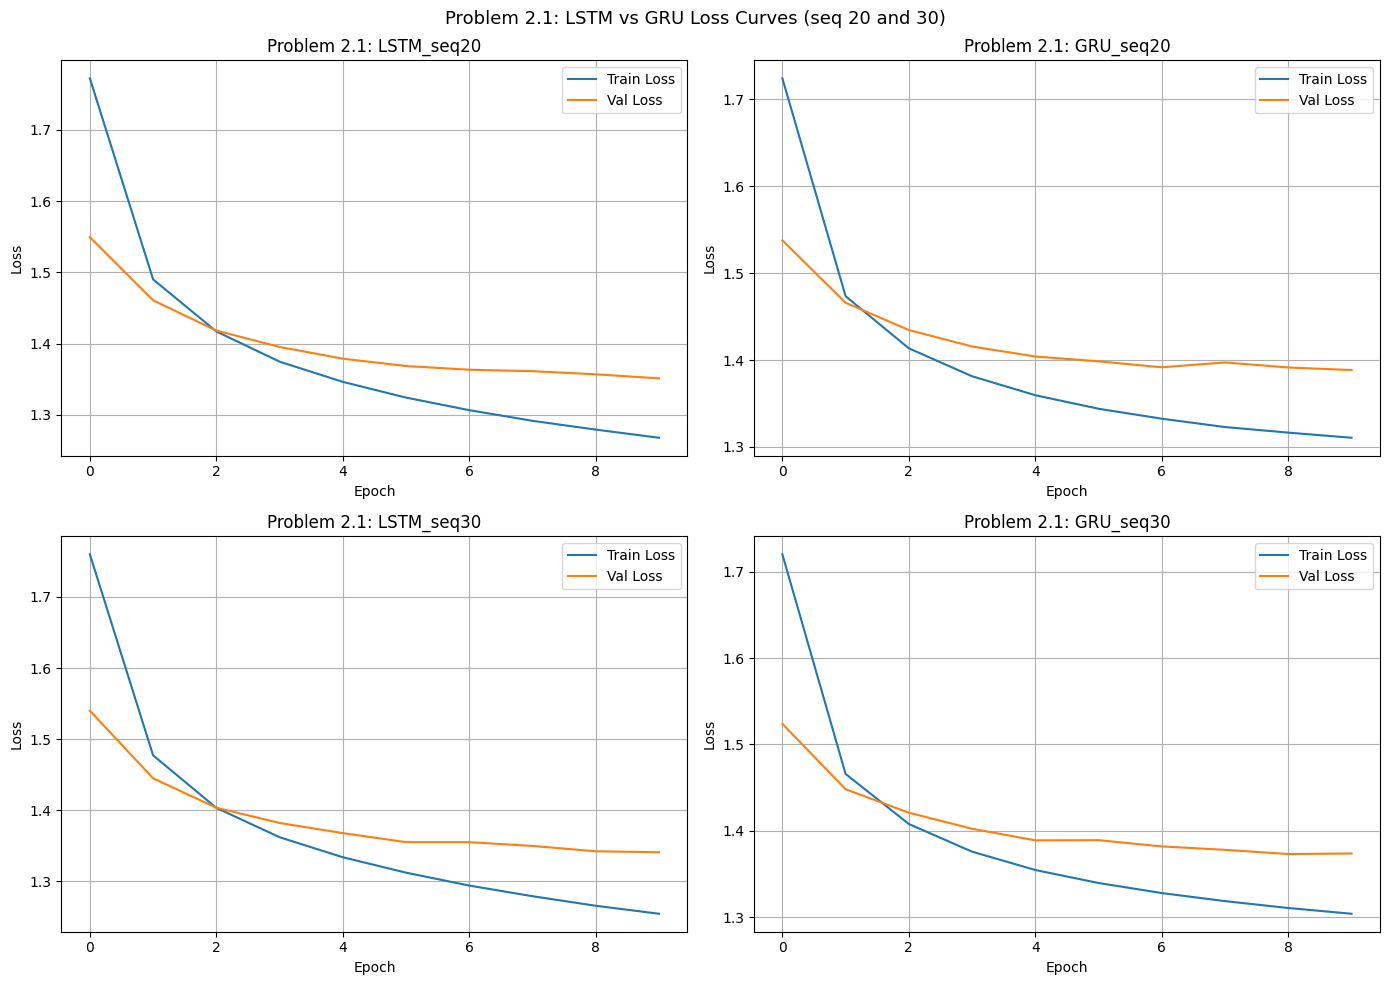

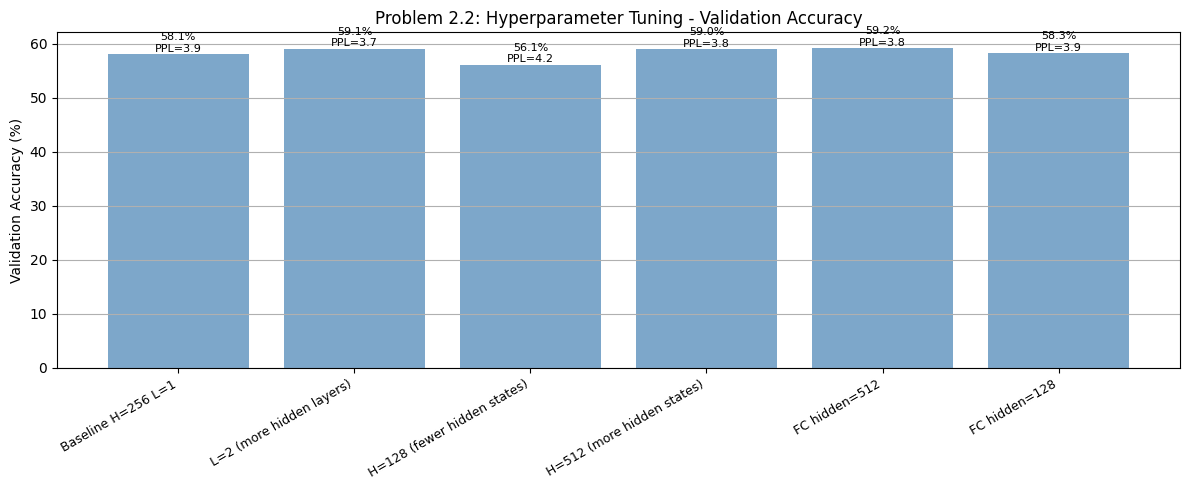

Plots saved.


In [14]:
# --- Problem 2: Summary Tables and Visualizations ---

print('\n' + '='*70)
print('PROBLEM 2 - FULL SUMMARY')
print('='*70)

# 2.1 Summary
print('\n--- Problem 2.1: LSTM vs GRU (seq 20, 30) ---')
print(f'{"Label":<20} {"Val Acc":<12} {"Val Loss":<12} {"PPL":<10} {"Time(s)":<10} {"Params":<12} {"FLOPs":<18} {"Size(KB)"}')
print('-'*110)
for k, v in results_p2.items():
    tl, vl, va, et, params, size, flops, ppl = v
    print(f'{k:<20} {va[-1]*100:<12.2f} {vl[-1]:<12.4f} {ppl:<10.2f} {et:<10.1f} {params:<12,} {flops:<18,} {size:.1f}')

# 2.2 Summary
print('\n--- Problem 2.2: Hyperparameter Tuning ---')
for k, v in results_hp.items():
    tl, vl, va, et, params, size, flops, ppl = v
    print(f'{k:<35} ValAcc={va[-1]*100:.2f}% ValLoss={vl[-1]:.4f} PPL={ppl:.2f} Time={et:.1f}s Params={params:,} Size={size:.1f}KB')

# 2.3 Summary
print('\n--- Problem 2.3: seq_len=50 ---')
for k, v in results_p23.items():
    tl, vl, va, et, params, size, flops, ppl = v
    print(f'{k:<20} ValAcc={va[-1]*100:.2f}% ValLoss={vl[-1]:.4f} PPL={ppl:.2f} Time={et:.1f}s Params={params:,} Size={size:.1f}KB')

# Plot Problem 2.1 loss curves
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for idx, (k, v) in enumerate(results_p2.items()):
    tl, vl, va, et, params, size, flops, ppl = v
    ax = axes[idx // 2][idx % 2]
    ax.plot(tl, label='Train Loss')
    ax.plot(vl, label='Val Loss')
    ax.set_title(f'Problem 2.1: {k}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True)
plt.suptitle('Problem 2.1: LSTM vs GRU Loss Curves (seq 20 and 30)', fontsize=13)
plt.tight_layout()
plt.savefig('p2_1_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot Problem 2.2 hyperparameter comparison
fig, ax = plt.subplots(figsize=(12, 5))
labels = list(results_hp.keys())
val_accs_hp = [results_hp[k][2][-1]*100 for k in labels]
ppls_hp = [results_hp[k][7] for k in labels]

ax.bar(range(len(labels)), val_accs_hp, color='steelblue', alpha=0.7)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Validation Accuracy (%)')
ax.set_title('Problem 2.2: Hyperparameter Tuning - Validation Accuracy')
ax.grid(True, axis='y')
for i, (acc, ppl) in enumerate(zip(val_accs_hp, ppls_hp)):
    ax.text(i, acc + 0.1, f'{acc:.1f}%\nPPL={ppl:.1f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('p2_2_hyperparam.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plots saved.')